#### 머신러닝 프레임워크 : scikit-learn
: 다양한 분류 및 회귀를 지원하며 검증.    
- 분류, 회귀, 클러스터링, 차원축소 + 샘플 데이터 제공

#### XOR 연산 학습해보기

In [4]:
xor_input = [
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
]
xor_input

[[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 0]]

In [6]:
import pandas as pd

In [7]:
xor_df = pd.DataFrame(xor_input)
xor_df

,0,1,2
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [10]:
# 데이터 구성
xor_data = xor_df.loc[:, [0, 1]]
xor_data

,0,1
0,0,0
1,0,1
2,1,0
3,1,1


In [13]:
# 라벨 데이터
xor_target = xor_df.loc[:, 2]
xor_target

0    0
1    1
2    1
3    0
Name: 2, dtype: int64

In [14]:
# 데이터 학습과 예측
from sklearn import svm, metrics

In [15]:
# 모델 만들기
clf = svm.SVC()

In [16]:
# 학습시키기
clf.fit(xor_data, xor_target)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [19]:
# 평가
pred = clf.predict(xor_data)
pred

array([0, 1, 1, 0])

In [20]:
# 정답률 구하기
metrics.accuracy_score(xor_target, pred)

1.0

In [23]:
# predict 구하지 않고 정답률 구하기
clf.score(xor_data, xor_target)

1.0

----
### 붓꽃의 품종 분류하기

In [24]:
iris = pd.read_csv('../Data/iris.csv')
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [25]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Name         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [27]:
# 품종(label)의 종류 확인
iris['Name'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [28]:
# 기본통계량
iris.describe()

,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [29]:
# 결측치 확인
iris.isna().sum()

SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
Name           0
dtype: int64

### 산포도(산점도, Scatter)

In [43]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'

In [ ]:
# 'Color' feature 추가
# Iris-setosa : red, Iris-versicolor : green, Iris-virginica : blue
color_temp = []

for name in iris['Name']:
    if name == 'Iris-setosa':
        color_temp.append('red')
    elif name == 'Iris-versicolor':
        color_temp.append('green')
    else :
        color_temp.append('blue')

iris['Color'] = color_temp
display(iris)

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,Color
0,5.1,3.5,1.4,0.2,Iris-setosa,red
1,4.9,3.0,1.4,0.2,Iris-setosa,red
2,4.7,3.2,1.3,0.2,Iris-setosa,red
3,4.6,3.1,1.5,0.2,Iris-setosa,red
4,5.0,3.6,1.4,0.2,Iris-setosa,red
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica,blue
146,6.3,2.5,5.0,1.9,Iris-virginica,blue
147,6.5,3.0,5.2,2.0,Iris-virginica,blue
148,6.2,3.4,5.4,2.3,Iris-virginica,blue


In [ ]:
# 1. 매핑할 딕셔너리 생성
color_dict = {
    'Iris-setosa': 'red',
    'Iris-versicolor': 'green',
    'Iris-virginica': 'blue'  # ⚠️ verginica의 오타(virginica)를 확인해 보시오!
}

# 2. .map()을 사용하여 한 줄로 새로운 컬럼 추가
iris['Color'] = iris['Name'].map(color_dict)

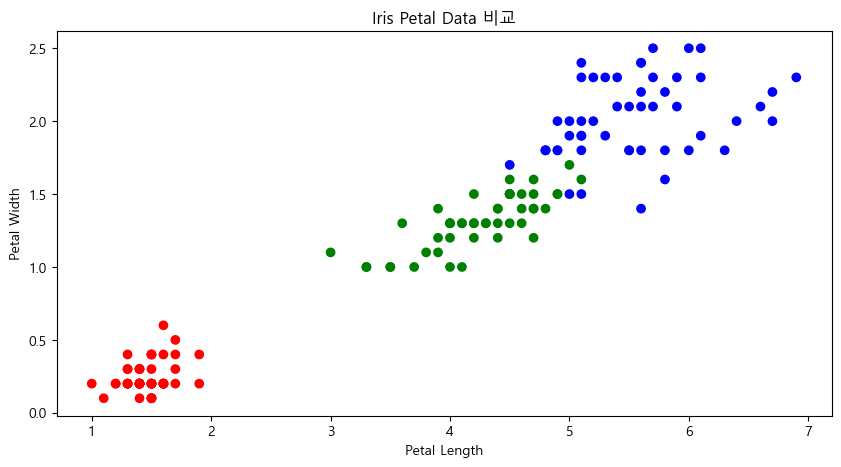

In [44]:
plt.figure(figsize = (10, 5))
plt.scatter(
    iris['PetalLength'],
    iris['PetalWidth'],
    c = iris['Color']
)
plt.title('Iris Petal Data 비교')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.show()

### ML을 위한 작업

In [47]:
# feature 만들기
iris_data = iris.iloc[:, 0:4]
iris_data

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [48]:
# target
iris_target = iris['Name']
iris_target

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: Name, Length: 150, dtype: object

#### Train / Test data 분리

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
train_data, test_data, train_target, test_target = \
    train_test_split(iris_data, iris_target)

#### 학습

In [52]:
clf = svm.SVC()

In [53]:
clf.fit(train_data, train_target)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [55]:
# 예측하기
pred = clf.predict(test_data)
pred

array(['Iris-virginica', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica', 'Iris-setosa', 'Iris-versicolor',
       'Iris-versicolor', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-virginica', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-setosa', 'Iris-setosa', 'Iris-virginica', 'Iris-virginica',
       'Iris-virginica', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-setosa', 'Iris-versicolor',
       'Iris-setosa', 'Iris-versicolor', 'Iris-versicolor',
       'Iris-virginica'], dtype=object)

In [56]:
# 정답률
metrics.accuracy_score(test_target, pred)

0.9473684210526315

In [57]:
# SepalLength : 4.1, SepalWidth : 3.5, PetalLength : 1.4, PetalWidth : 0.2 => 품종 예측
clf.predict([
    [4.1, 3.5, 1.4, 0.2]
])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['Iris-setosa'], dtype=object)

In [58]:
# SepalLength : 8.1, SepalWidth : 9.5, PetalLength : 11.4, PetalWidth : 1.2 => 품종 예측
clf.predict([
    [8.1, 9.5, 11.4, 1.2]
])

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['Iris-setosa'], dtype=object)